# Introduction to Hyperalignment
This section introduces the core ideas behind hyperalignment and walks the reader through a concise, hands-on tutorial demonstrating how hyperalignment can be implemented at the matrix level. While the toolbox offers a set of ready-to-use pipeline functions, working directly with the underlying matrix operations provides greater transparency and enables users to design more flexible, customized analyses tailored to their own research needs.

## Background and Motivation: Why Hyperalignment?

```{image} pic/introduction/fig1.png
:alt: fig1
:width: 600px
```

In the schematic illustration above, the red and blue trajectories represent the time courses of multivoxel activity patterns from two different individuals within the same small cortical region, here simplified to three voxels. Although these two participants are exposed to identical stimuli and are assumed to encode the same underlying information, their neural responses occupy different coordinates in voxel space. This mismatch does not necessarily reflect differences in the represented content, but rather individual variability in functional topographies and their imperfect correspondence with anatomical alignment.

As a result, directly comparing activity patterns across individuals—voxel by voxel—can be misleading: patterns that are functionally equivalent may appear dissimilar simply because they are expressed along different axes of the local representational space. Hyperalignment was introduced to address precisely this issue. Instead of enforcing correspondence at the level of anatomical locations, hyperalignment seeks a transformation that brings individual-specific representational spaces into a shared coordinate system, such that patterns evoked by the same information become geometrically aligned. In this way, hyperalignment preserves the structure of each individual’s neural representations while reducing inter-subject variability that arises from idiosyncratic functional organization, enabling meaningful comparison of multivariate patterns across brains.

From this perspective, the central question is how to define a transformation that aligns individual representational spaces while preserving their internal structure. Several approaches have been proposed to address this problem. For example, Shared Response Models (SRM) learn a low-dimensional shared latent space together with subject-specific mappings. While such models provide a flexible framework for capturing shared neural responses, they are not the focus of this tutorial.

Instead, we concentrate on hyperalignment methods based on Procrustes rotation. In this approach, each individual’s data are mapped into a common representational space through an orthogonal transformation, which preserves the geometric relationships among multivoxel response patterns. This formulation is conceptually transparent, computationally efficient, and can be implemented directly using basic matrix operations. In the following sections, we introduce Procrustes rotation as the core mechanism of hyperalignment and demonstrate how it supports the construction of a shared representational space across individuals.

## Procrustes Rotation: Core of Hyperalignment

### Concept and Formulation

At the core of Procrustes-based hyperalignment lies a simple yet powerful idea: although different individuals may encode the same information, their neural response patterns are often expressed along different axes in voxel space. As a result, representational spaces that are functionally equivalent can appear misaligned when compared directly. Procrustes rotation addresses this issue by seeking a rigid transformation that reorients one representational space to best match another, without altering its internal structure.

Crucially, this transformation is restricted to rotation (and reflection). By enforcing this constraint, Procrustes rotation preserves the geometry of the data—namely, the relative distances and angles between multivoxel activity patterns—while allowing individual-specific representational axes to differ. This property makes it well suited for hyperalignment, where the goal is to align shared representational structure across subjects rather than impose voxel-wise correspondence.

Formally, consider two data matrices $X \in \mathbb{R}^{T \times V}$ and $Y \in \mathbb{R}^{T \times V}$, representing multivoxel response patterns from two individuals (or from an individual and a reference space) measured over the same set of $T$ time points and $V$ voxels. Procrustes rotation seeks an orthogonal transformation matrix $R \in \mathbb{R}^{V \times V}$ that aligns $X$ to $Y$ by minimizing the discrepancy between the transformed and target representations:

$$
\min_{R}\; \|XR - Y\|_F^2
\quad \text{subject to} \quad
R^\top R = I .
$$


Here, $||\cdot||_F$ denotes the Frobenius norm, which measures the overall mismatch between the transformed and target data. The orthogonality constraint $R^\top R = I$ ensures that the transformation preserves the scale and geometry of the original representational space, allowing only a reorientation of its axes. Under this constraint, the optimal solution does not distort the data but instead finds the rotation that maximizes correspondence between functionally equivalent response patterns.

This formulation explains why Procrustes rotation can serve as the core operation of hyperalignment: it provides a principled way to reduce inter-subject variability arising from idiosyncratic functional organization while retaining the representational structure that is shared across individuals. In the next subsection, we show how this optimization problem admits a closed-form solution via singular value decomposition (SVD), enabling an efficient and transparent implementation at the matrix level.

### Example of one ROI

#### Procrustes Transformation Function

The function `R = procrustes(X, Y, reflection, scaling)` computes a transformation matrix that rotates the data matrix `X` to best match `Y` under a Procrustes framework. The returned matrix `R` can then be applied to `X` to align it with the target representational space defined by `Y`.

In this function, the optional arguments `reflection` and `scaling` control the class of transformations that are permitted:

- **`reflection`**  
  Determines whether reflections are allowed in addition to rotations.  
  - When set to `True`, the transformation may include a reflection, allowing a more flexible alignment.  
  - When set to `False`, only proper rotations are permitted, preserving orientation.  
  In most hyperalignment applications, reflections are allowed, as they do not alter representational geometry and can improve alignment when axis directions differ across individuals.

- **`scaling`**  
  Determines whether isotropic scaling is allowed.  
  - When set to `True`, the transformation may rescale the data.  
  - When set to `False`, the transformation preserves the original scale of the representational space.  
  In hyperalignment, scaling is typically disabled (`scaling=False`) to ensure that alignment reflects a reorientation of representational axes rather than changes in response magnitude.

Unless explicitly stated otherwise, hyperalignment analyses commonly allow reflection but disallow scaling, resulting in an orthogonal transformation that preserves the geometry of multivoxel response patterns.


Data input: 451 timepoint, 119 node, 2 subjects
Data input: 451 timepoint, 119 node, 2 subjects


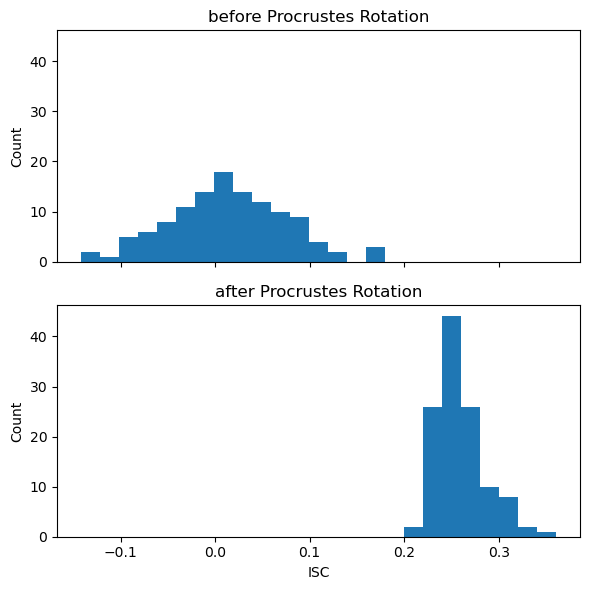

mean ISC before Procurstes Rotation is 0.01434278481256255
mean ISC after Procurstes Rotation is 0.2591539740703244


In [1]:
import os
# --------------------------------------------------
# (Optional) Limit the number of threads used by BLAS
# This is recommended on Linux to avoid oversubscription
# when running searchlight computations in parallel.
# --------------------------------------------------
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/data/disk0/gaoyixin/clean_program/HAkit_v1.0')
from HAkit.src.procrustes import procrustes
from HAkit.stat.isc import isc_mat_nb


data_dir = '/data/disk0/gaoyixin/clean_program/HAkit_demo/tutorial_data'
os.chdir(f"{data_dir}/tutorial_1")

sub1 = np.load('sub1_sl.npy')
sub2 = np.load('sub2_sl.npy')

# rotate sub1 to match sub2
R = procrustes(X=sub1, Y=sub2, reflection=True, scaling=False)  # X is source, Y is target
sub1_aligned = sub1 @ R  # apply the transformation matrix R

# ISC before procrustes
mat_raw = np.stack([sub1, sub2], axis=2)
isc_raw = isc_mat_nb(mat=mat_raw, pairwise=True, metric='correlation', n_jobs=1, summary_statistic='mean')['ISC_mean']

# ISC after procrustes
mat_new = np.stack([sub1_aligned, sub2], axis=2)
isc_aligned = isc_mat_nb(mat=mat_new, pairwise=True, metric='correlation', n_jobs=1, summary_statistic='mean')['ISC_mean']

# visualization
def plot_stacked_hist(v1, v2, bins=20, title1='before', title2='after'):
    v1 = np.asarray(v1)
    v2 = np.asarray(v2)

    xmin = min(v1.min(), v2.min())
    xmax = max(v1.max(), v2.max())

    h1, _ = np.histogram(v1, bins=bins, range=(xmin, xmax))
    h2, _ = np.histogram(v2, bins=bins, range=(xmin, xmax))
    ymax = max(h1.max(), h2.max())

    fig, axes = plt.subplots(
        2, 1, figsize=(6, 6),
        sharex=True, sharey=True
    )

    axes[0].hist(v1, bins=bins, range=(xmin, xmax))
    axes[0].set_ylabel("Count")
    axes[0].set_title(title1)

    axes[1].hist(v2, bins=bins, range=(xmin, xmax))
    axes[1].set_xlabel("ISC")
    axes[1].set_ylabel("Count")
    axes[1].set_title(title2)

    axes[0].set_ylim(0, ymax * 1.05)

    plt.tight_layout()
    plt.show()

plot_stacked_hist(isc_raw, isc_aligned, bins=25, title1='before Procrustes Rotation', title2='after Procrustes Rotation')
print(f"mean ISC before Procurstes Rotation is {isc_raw.mean()}")
print(f"mean ISC after Procurstes Rotation is {isc_aligned.mean()}")

## Common Space

```{image} pic/introduction/fig2.png
:alt: fig2
:width: 600px
```

The goal of hyperalignment is not simply to align one subject to another, but to map individual neural responses into a **common representational space**. This common space serves as a shared coordinate system in which neural activity patterns from different individuals can be meaningfully compared, combined, or modeled.

Because fine-scale functional organization varies across brains, the same information may be encoded along different voxel axes in different individuals. Directly comparing activity patterns in native voxel space can therefore obscure shared representational structure. By projecting each individual’s data into a common space, hyperalignment removes idiosyncratic axis differences while preserving the internal geometry of neural representations. As a result, patterns evoked by the same information become aligned across individuals, even though their original anatomical layouts may differ.

In practice, the common space provides a reference frame that enables cross-subject analyses, such as pattern averaging, decoding, or representational similarity analysis, without requiring strict voxel-wise correspondence. Importantly, this space is not tied to any single individual, but reflects the shared representational structure supported by the group.

Multiple approaches have been proposed to construct a common representational space. The current toolbox includes implementations based on **Procrustes rotation** as well as **PCA-based methods**, allowing users to choose different alignment strategies depending on their analytical goals.

### Procrustes-rotation-based Common Space

```{image} pic/introduction/fig3.png
:alt: fig3
:width: 600px
```

In practice, the common representational space in Procrustes-based hyperalignment is often constructed using an **iterative template algorithm**. The central idea is to progressively align individual subjects into a shared space and update the group template based on the aligned data, rather than relying on any single subject as a fixed reference.

As illustrated in the schematic above, the procedure typically proceeds in two stages.

**First stage: sequential alignment and template initialization.**  
One subject is first selected as an initial reference space. A second subject is then aligned to this reference using Procrustes rotation, and the aligned data are averaged with the reference to form an updated template. Subsequently, additional subjects are aligned one by one to the current template, and the template is updated by averaging the newly aligned data with the existing template. After all subjects have been processed once, this procedure yields an initial (first-level) common template.

**Second stage: refinement using the group template.**  
In the next step, all subjects are independently aligned to the first-level template obtained above. The aligned representations from all subjects are then averaged to produce the final common representational space. This second pass removes potential biases introduced by the initial reference choice and stabilizes the group-level template.

Formally, let $B_i \in \mathbb{R}^{T \times V}$ denote the data matrix of subject $i$, and let $R_i \in \mathbb{R}^{V \times V}$ be the subject-specific orthogonal transformation obtained via Procrustes rotation. The common template $M$ is defined as the average of the aligned data:

$$
M = \frac{1}{N} \sum_{i=1}^{N} B_i R_i ,
$$

where each $R_i$ is chosen to minimize the discrepancy between the transformed subject data and the current template:

$$
\arg\min_{R_i} \sum_{i=1}^{N} \| B_i R_i - M \|_F .
$$

This iterative procedure captures the shared representational structure across individuals while allowing each subject to retain an idiosyncratic mapping into the common space. Importantly, the resulting template is not tied to any single subject, but reflects the group-level organization of representational geometry, consistent with the original formulation of hyperalignment.


In [2]:
from HAkit.src.local_template import compute_template

sub1 = np.load('sub1_sl.npy')
sub2 = np.load('sub2_sl.npy')
sub3 = np.load('sub3_sl.npy')

dss = np.stack([sub1, sub2, sub3], axis=0)
M_pr = compute_template(dss, sl=None, kind='procrustes')  # dss: nsub*nt*nv

### PCA-based Common Space

```{image} pic/introduction/fig4.png
:alt: fig4
:width: 600px
```

In addition to Procrustes-based iterative alignment, a common representational space can also be constructed using a **PCA-based approach**. This method estimates the shared representational structure across subjects by identifying dominant patterns of variance in a low-dimensional latent space, and then mapping the result back to the original voxel (or vertex) space. Because all subjects contribute symmetrically to the PCA step, this approach avoids the dependence on subject ordering that can arise in sequential Procrustes alignment.

The PCA-based procedure can be summarized in three conceptual steps.

**Step A: PCA-based template estimation.**  
Response matrices from all subjects are concatenated along the feature dimension, and singular value decomposition (SVD) is applied. A subset of principal components is retained to form a low-dimensional template $M_{\mathrm{PC}}$, which captures the dominant representational structure shared across subjects.

**Step B: Projection back to the original feature space via Procrustes rotation.**  
The PCA-derived template $M_{\mathrm{PC}}$ resides in a reduced latent space. To express this template in the original voxel (or vertex) space, an orthogonal transformation matrix $R$ is estimated by minimizing the discrepancy between the rotated PCA template and individual subject data:

$$
R = \arg\min_{R} \sum_{p=1}^{n} \| M_{\mathrm{PC}} R - B_{(p)} \|_F^2 .
$$

Here, $B_{(p)}$ denotes the data matrix of subject $p$. In this context, Procrustes rotation is used solely as a projection step, allowing the PCA-based template to be represented in the original feature space rather than defining the template itself.

**Step C: Template aggregation.**  
After projection, the aligned representations are aggregated to form the final common template, which can then be used as a reference space for subsequent hyperalignment or cross-subject analyses.

Overall, the PCA-based approach provides an alternative strategy for constructing a common representational space. By estimating shared structure in a single decomposition step, it reduces sensitivity to subject ordering while still yielding a template that can be expressed in the original representational space.


In [3]:
M_pca = compute_template(dss, sl=None, kind='pca', common_topography=True)  
# common_topography: project data from dimension space back into vertex/voxel space

## Transformation Matrices

The transformation matrices are computed using Procrustes rotation, as described in Section 2. In this step, we derive a subject-specific mapping from the raw response data to the common representational space.

### Estimation

In [4]:
# PR-common space
sub1_pca_R = procrustes(X=sub1, Y=M_pca)
sub2_pca_R = procrustes(X=sub2, Y=M_pca)
sub3_pca_R = procrustes(X=sub3, Y=M_pca)

sub1_pr_R = procrustes(X=sub1, Y=M_pr)
sub2_pr_R = procrustes(X=sub2, Y=M_pr)
sub3_pr_R = procrustes(X=sub3, Y=M_pr)

### Apply Transformation Matrics

Data input: 451 timepoint, 119 node, 3 subjects
Data input: 451 timepoint, 119 node, 3 subjects
Data input: 451 timepoint, 119 node, 3 subjects


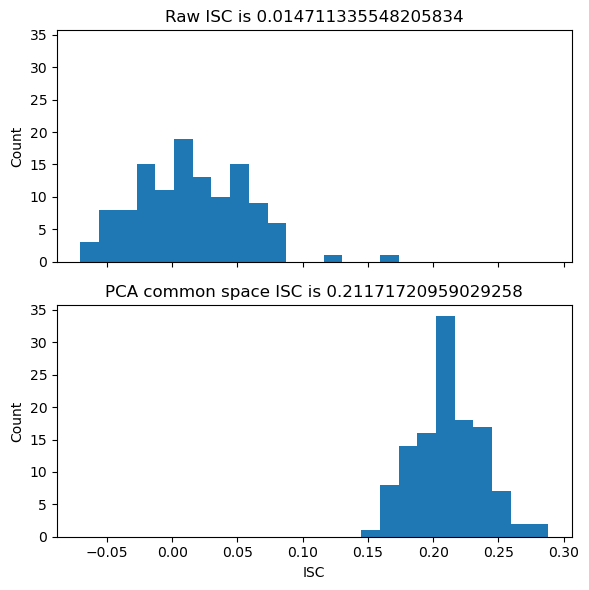

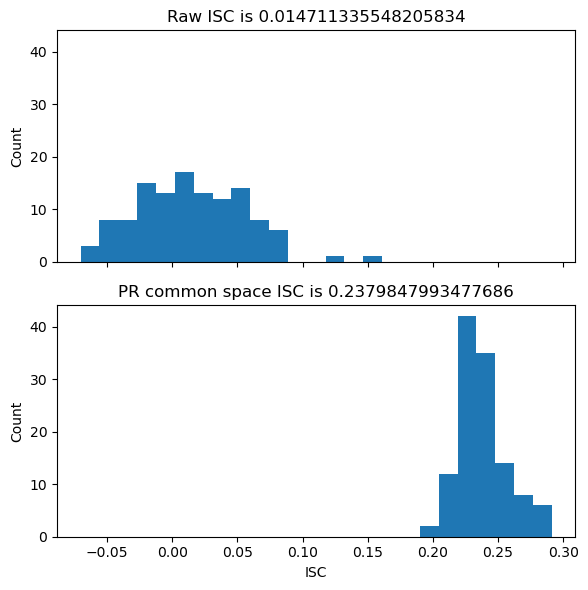

In [5]:
# directly use @
sub1_pca_aligned = sub1 @ sub1_pca_R
sub2_pca_aligned = sub2 @ sub2_pca_R
sub3_pca_aligned = sub3 @ sub3_pca_R
 

sub1_pr_aligned = sub1 @ sub1_pr_R
sub2_pr_aligned = sub2 @ sub2_pr_R
sub3_pr_aligned = sub3 @ sub3_pr_R

# ISC
mat_raw = np.stack([sub1, sub2, sub3], axis=2)
isc_raw = isc_mat_nb(mat=mat_raw, pairwise=True, metric='correlation', n_jobs=1, summary_statistic='mean')['ISC_mean']

mat_pca = np.stack([sub1_pca_aligned, sub2_pca_aligned, sub3_pca_aligned], axis=2)
isc_pca = isc_mat_nb(mat=mat_pca, pairwise=True, metric='correlation', n_jobs=1, summary_statistic='mean')['ISC_mean']

mat_pr = np.stack([sub1_pr_aligned, sub2_pr_aligned, sub3_pr_aligned], axis=2)
isc_pr = isc_mat_nb(mat=mat_pr, pairwise=True, metric='correlation', n_jobs=1, summary_statistic='mean')['ISC_mean']

# plot
plot_stacked_hist(isc_raw, isc_pca, bins=25, title1=f"Raw ISC is {isc_raw.mean()}", title2 = f"PCA common space ISC is {isc_pca.mean()}")
plot_stacked_hist(isc_raw, isc_pr, bins=25, title1=f"Raw ISC is {isc_raw.mean()}", title2 = f"PR common space ISC is {isc_pr.mean()}")

## Searchlight Methods

### Concepts

```{image} pic/introduction/fig5.png
:alt: fig5
:width: 600px
```

**Whole-brain searchlight-based hyperalignment and construction of a common representational space.**  
Following the representational space framework proposed by Haxby and colleagues, hyperalignment is performed across the entire cortex using a dense tiling of overlapping searchlights. Each searchlight defines a local multivariate response space in which neural activity patterns are compared and aligned across individuals. At this local scale, subject-specific transformation matrices are estimated to reorient individual representational spaces into a shared coordinate system.

Critically, this procedure is repeated for searchlights distributed across the whole cortex. Because searchlights overlap, each voxel or surface vertex participates in multiple local alignment problems and is associated with multiple transformation matrices derived from neighboring searchlights. Rather than selecting a single transformation, these locally estimated mappings are combined to form a voxel-wise (or vertex-wise) transformation using distance-weighted averaging, such that transformations from searchlights centered closer to a given location contribute more strongly.

Through this aggregation, hyperalignment yields a smooth, continuous mapping from each individual’s native representational space into a common model space at the whole-brain level. Applying the aggregated transformation matrices to the raw response data projects individual neural activity into this common representational space, in which the geometry of population-level representations is shared across subjects. This framework enables whole-brain analyses that respect local representational structure while supporting global alignment, allowing multivariate patterns to be compared, averaged, and modeled across individuals despite substantial variability in cortical organization.


### Searchlight Common Space

To perform searchlight-based hyperalignment, the first step is to define a set of searchlights that tile the cortical surface. In this tutorial, we use the `neuroboros` package to load a predefined searchlight list for convenience, rather than constructing searchlights manually.

The response data are assumed to be organized as a matrix of shape `nt × nv`, where `nt` denotes the number of time points and `nv` denotes the number of vertices. In our demonstration, the data matrix has a shape of `451 × 9675`, corresponding to the left hemisphere with the medial wall removed.

A searchlight list is represented as a list of index arrays, where each element defines a local neighborhood of vertices. For example, a searchlight list of the form `[[1, 2, 3], [4, 5, 6], ...]` specifies multiple searchlights, with each sublist containing the vertex indices that belong to a single searchlight. During hyperalignment, local representational spaces are constructed and aligned independently within each of these searchlights, and the resulting transformations are later combined to produce a whole-brain mapping.


In [6]:
from HAkit.src.searchlight import searchlight_template
import neuroboros as nb
import numpy as np

sub1_data = np.load('sub1_left.npy')
sub2_data = np.load('sub2_left.npy')
sub3_data = np.load('sub3_left.npy')

# Stack data across subjects
# Resulting shape: (n_subjects, nt, nv)
dss = np.stack([sub1_data, sub2_data, sub3_data], axis=0)

# --------------------------------------------------
# Load predefined searchlights and vertex-wise distances
# sls   : list of searchlights, each defined by vertex indices
# dists : distances between vertices and searchlight centers,
#         used later for distance-weighted aggregation
# --------------------------------------------------
radius = 20  # searchlight radius in millimeters
sls, dists = nb.sls(
    lr='l',
    radius=radius,
    space='onavg-ico32',
    return_dists=True
)

# --------------------------------------------------
# Construct a PCA-based common representational space
# using searchlight-based alignment
# --------------------------------------------------
M_sls = searchlight_template(
    dss,
    sls,
    dists,
    radius,
    n_jobs=10,
    tmpl_kind='pca'
)


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    4.8s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    5.5s
[Parallel(n_jobs=10)]: Done 430 tasks      | elapsed:    6.6s
[Parallel(n_jobs=10)]: Done 780 tasks      | elapsed:    8.1s
[Parallel(n_jobs=10)]: Done 1230 tasks      | elapsed:   10.1s
[Parallel(n_jobs=10)]: Done 1780 tasks      | elapsed:   12.6s
[Parallel(n_jobs=10)]: Done 2430 tasks      | elapsed:   15.4s
[Parallel(n_jobs=10)]: Done 3180 tasks      | elapsed:   18.8s
[Parallel(n_jobs=10)]: Done 4030 tasks      | elapsed:   22.5s
[Parallel(n_jobs=10)]: Done 4980 tasks      | elapsed:   26.7s
[Parallel(n_jobs=10)]: Done 6030 tasks      | elapsed:   31.4s
[Parallel(n_jobs=10)]: Done 7180 tasks      | elapsed:   36.5s
[Parallel(n_jobs=10)]: Done 8430 tasks      | elapsed:   42.1s
[Parallel(n_jobs=10)]: Done 9675 out of 9675 | elapsed:   47.6s finished


The code shown above provides a relatively complete implementation for constructing a common representational space and is generally sufficient for small to moderate sample sizes. In such settings, it offers a clear and accessible way to understand and experiment with searchlight-based hyperalignment.

However, when applied to larger datasets, this implementation may encounter limitations related to computational efficiency and memory usage. In addition, more advanced customization—such as modifying weighting schemes or intermediate processing steps—requires direct edits to the corresponding components in the `src` module.

For these reasons, this part of the code is primarily intended for educational purposes, exploratory analyses, and relatively clean small- to medium-sized datasets. Building on this foundation, the computational modules provided in the toolbox offer additional utilities and optimizations designed to support more demanding analyses and large-scale applications.


### Searchlight Transformation Matrices

As with the common space computation, transformation matrices are initially estimated within individual searchlights and subsequently aggregated to yield a whole-brain transformation matrix.

Data input: 451 timepoint, 9675 node, 3 subjects
Data input: 451 timepoint, 9675 node, 3 subjects


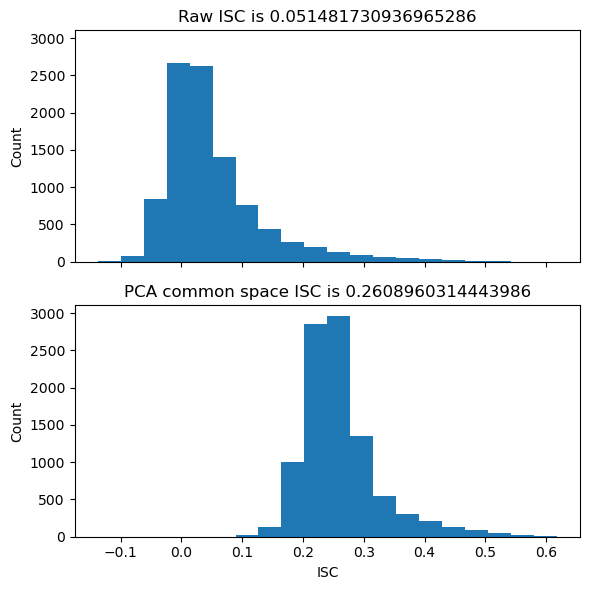

In [7]:
from HAkit.src.searchlight import searchlight_procrustes
sub1_R_sls = searchlight_procrustes(sub1_data, M_sls, sls, dists, radius)
sub2_R_sls = searchlight_procrustes(sub2_data, M_sls, sls, dists, radius)
sub3_R_sls = searchlight_procrustes(sub3_data, M_sls, sls, dists, radius)

sub1_aligned_left = sub1_data @ sub1_R_sls
sub2_aligned_left = sub2_data @ sub2_R_sls
sub3_aligned_left = sub3_data @ sub3_R_sls

# ISC
mat_raw = np.stack([sub1_data, sub2_data, sub3_data], axis=2)
isc_raw = np.nan_to_num(isc_mat_nb(mat=mat_raw, pairwise=True, metric='correlation', n_jobs=10, summary_statistic='mean')['ISC_mean'], nan=0.0)

mat_pca = np.stack([sub1_aligned_left, sub2_aligned_left, sub3_aligned_left], axis=2)
isc_pca = np.nan_to_num(isc_mat_nb(mat=mat_pca, pairwise=True, metric='correlation', n_jobs=10, summary_statistic='mean')['ISC_mean'], nan=0.0)

# plot
plot_stacked_hist(isc_raw, isc_pca, bins=20, title1=f"Raw ISC is {isc_raw.mean()}", title2 = f"PCA common space ISC is {isc_pca.mean()}")

### Surface Searchlight

There were two ways to generate surface searchlight list. One is shown above--using neuroboros to load predefined searchlight list, which is convient. But the nb.sls function only provide three surface space: 'onavg-ico32'(recommended), 'fslr-ico32' and 'fsavg-ico32', and the searchlight radius should not be larger than 20.
Our package provide the function to generate searchlight based on your own surface data, which is also based on dijkatra distance like neuroboros. We will provide a detailed introduction to these two ways.

In [8]:
sls, dists = nb.sls(
    lr='l',                       # hemisphere: 'l' or 'r'
    radius=20,                    # searchlight radius (<=20)
    space='onavg-ico32',          # surface space
    center_space='onavg-ico8',    # downsample space or False
    mask=False,                   # whether to remove medial wall
    return_dists=True)            # whether to return distance list


The function `nb.sls` is used to generate a surface-based searchlight list and the corresponding distance information. Its key parameters are explained below.

- **`lr`**  
  Specifies the hemisphere on which searchlights are defined.  
  `'l'` indicates the left hemisphere, and `'r'` indicates the right hemisphere.

- **`radius`**  
  Defines the radius of each searchlight (in millimeters).  
  When using predefined surface spaces in `neuroboros`, the radius should not exceed **20 mm**.

- **`space`**  
  Specifies the surface space on which the response data are defined.  
  `'onavg-ico32'`, `'fslr-ico32'` or `'fsavg-ico32'`

- **`center_space`**  
  Controls how searchlight centers are selected and provides an optional **downsampling strategy**.  
  When `center_space='onavg-ico8'`, searchlight centers are defined on a lower-resolution surface (ico8), while the searchlights themselves are constructed on the higher-resolution surface specified by `space` (ico32).  
  Concretely, for each vertex in the ico8 surface, its spatial location is used as the center of a searchlight, and all vertices from the ico32 surface that fall within the specified radius are included in that searchlight.  
  This approach reduces the total number of searchlights while preserving coverage of the full high-resolution surface, leading to substantial computational savings without changing the resolution of the response data.

  Setting `center_space=False` disables downsampling and uses all vertices in `space` as searchlight centers.

- **`mask`**  
  Specifies whether to exclude masked vertices (e.g., the medial wall).  
  When set to `False`, no additional masking is applied.

- **`return_dists`**  
  If set to `True`, the function additionally returns the distances between each vertex and its corresponding searchlight center.  
  These distances are typically used for distance-weighted aggregation when combining overlapping searchlight results.


In [9]:
from HAkit import gensls
# using .surf.gii to extract coordinate and faces information
surfgii = {'l': 'tpl-fsLR_den-32k_hemi-L_midthickness.surf.gii'}

# read the coordinate and faces information in surfgii
surf_data = gensls.get_surfgii_data(surfgii)

# generate the searchlight for the whole cortex
sls, dists = gensls.generate_searchlight_surf(
    lr='l', 
    surface_file=surf_data, 
    center_file=None, 
    radius=15, 
    cortical_mask=None
    )


If you want to exclude the medial wall or restrict searchlights to a specific cortical region, you can either define a cortical mask during searchlight generation or update an existing searchlight list using the provided `sls_update` function.


In [10]:
# --------------------------------------------------
# Adding a cortical mask to exclude the medial wall
# --------------------------------------------------
import joblib

# Load a predefined cortical mask (False for medial wall vertices)
cortical_mask_lr = joblib.load('fs32k_medial.pkl')

sls_cort, dists_cort = gensls.generate_searchlight_surf(
    lr='l',
    surface_file=surf_data,
    center_file=None,
    radius=15,
    cortical_mask=cortical_mask_lr
)


In [ ]:
# --------------------------------------------------
# Updating an existing searchlight list to remove
# medial wall vertices
# --------------------------------------------------
medial_wall = {lr: ~cortical_mask_lr[lr].astype(bool) for lr in 'lr'}

sls_new, dists_new = gensls.sls_update(
    {'l': sls},
    {'l': dists},
    medial_wall,
    'l'
)


You can also specify a **sparser surface** as the set of searchlight centers to achieve a downsampling effect.


In [ ]:
# --------------------------------------------------
# Using a sparser surface as searchlight centers
# --------------------------------------------------
center_surfgii = {
    'l': 'tpl-fsLR_den-8k_hemi-L_midthickness.surf.gii'
}

# Load vertex coordinates from the downsampled surface
center_surf_data = gensls.get_surfgii_data(center_surfgii)

sls_dsample, dists_dsample = gensls.generate_searchlight_surf(
    lr='l',
    surface_file=surf_data,
    center_file=center_surf_data,
    radius=15,
    cortical_mask=None
)


### Volume Searchlight

Same as surface searchlight, our function support both CIFTI sub-cortical volume, or common NIFTI files.

In [ ]:
# cifti sub-cortical volume
mask_dense_left = gensls.dsample.downsample_cifti_subcortical(
    cifti_file='xSfrNGRd_rid000005_raiders_run-01_TS.dtseries.nii',  # cifti filename
    N=None, 
    mask3d_out=None, 
    sls_type='seed',                                                 
    voxel_sizes=None, 
    drop_all_zero_columns=True, 
    whole_mask=False, 
    hemi_mask=True)['l']

sls_info_dense = gensls.generate_searchlight_vol(
    mask_dense=mask_dense_left, 
    mask_center=None, 
    radius=3, 
    threshold=0.2, 
    njobs=10, 
    verbose=5)

In [ ]:
# cifti sub-cortical volume downsampling
mask_dense = gensls.dsample.downsample_cifti_subcortical(
    cifti_file=os.path.join(test_dir, 'xSfrNGRd_rid000005_raiders_run-01_TS.dtseries.nii'),
    N=1994, 
    mask3d_out=None, 
    sls_type='seed', 
    voxel_sizes=None, 
    drop_all_zero_columns=True, 
    whole_mask=False, 
    hemi_mask=True)['whole']

mask_center = gensls.dsample.downsample_cifti_subcortical(
    cifti_file=os.path.join(test_dir, 'xSfrNGRd_rid000005_raiders_run-01_TS.dtseries.nii'),
    N=1994, 
    mask3d_out=None, 
    sls_type='not_seed', 
    voxel_sizes=None, 
    drop_all_zero_columns=True, 
    whole_mask=False, 
    hemi_mask=True)['whole']

print(f"mask dense: {np.sum(mask_dense)}, mask center: {np.sum(mask_center)}")

radius=3
threshold = 0.2
njobs=10
verbose=2
sls_info = gensls.generate_searchlight_vol(
    mask_dense, 
    mask_center, 
    radius, 
    threshold, 
    njobs, 
    verbose)

In [ ]:
# nifti is supported as well
sls_info = gensls.generate_searchlight_vol(
    mask_dense='HCPex_2mm_cortical_mask.nii', 
    mask_center=None, 
    radius=3, 
    threshold=0.2, 
    njobs=2, 
    verbose=10)

Next Chapter will introduce the main part of our toolbox and pipeline recommended.